<a href="https://colab.research.google.com/github/upayanadhikary25-27-a11y/Cancer_ML_Project/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ---------------------------------------------------
# STEP 1: Import libraries
# ---------------------------------------------------
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules




In [9]:
# ---------------------------------------------------
# STEP 2: Load the dataset
# ---------------------------------------------------
transactions = []

with open("retail.dat") as f:
    for line in f:
        transactions.append(line.strip().split())

print("Total_Transactions:", len(transactions))


Total_Transactions: 88162


In [10]:
# ---------------------------------------------------
# STEP 3: Encode transactions
# ---------------------------------------------------

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)
print("DATA SET SHAPE:",df.shape)

DATA SET SHAPE: (88162, 16470)


In [11]:
# ---------------------------------------------------
#  STEP 4: Generate frequent itemsets
# ---------------------------------------------------

frequent_itemsets = apriori(df, min_support=0.05,
                            use_colnames=True)
print("/n Frequent Itemsets")
print(frequent_itemsets.head())

/n Frequent Itemsets
    support itemsets
0  0.172036     (32)
1  0.176902     (38)
2  0.574794     (39)
3  0.169517     (41)
4  0.477927     (48)


In [12]:
# ---------------------------------------------------
# STEP 5: Generate association rules
# ---------------------------------------------------

rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.3)
print("/n Association Rules")
print(rules.head())


/n Association Rules
  antecedents consequents  antecedent support  ...   jaccard  certainty  kulczynski
0        (32)        (39)            0.172036  ...  0.147333  -0.040766    0.362154
1        (32)        (48)            0.172036  ...  0.163067   0.099173    0.360188
2        (38)        (39)            0.176902  ...  0.184977   0.208174    0.433728
3        (38)        (48)            0.176902  ...  0.159560   0.060211    0.348949
4        (41)        (39)            0.169517  ...  0.210567   0.444348    0.494486

[5 rows x 14 columns]


After executing the cell above, the deprecation warnings from `jupyter_client` should no longer appear in the output. Keep in mind that this hides *all* warnings, so use it judiciously. If you want to see warnings again, you can remove the `warnings.filterwarnings('ignore')` line or change it to `warnings.filterwarnings('default')`.

In [13]:
# ---------------------------------------------------
# STEP 6: Sort rules by lift
# ---------------------------------------------------

rules = rules.sort_values(by=['lift'], ascending=False)
print("/n Sorted Rules")
print(rules.head())

/n Sorted Rules
   antecedents consequents  antecedent support  ...   jaccard  certainty  kulczynski
16        (41)    (39, 48)            0.169517  ...  0.200594   0.242473    0.372818
15    (41, 48)        (39)            0.102289  ...  0.140769   0.569175    0.481084
14    (39, 41)        (48)            0.129466  ...  0.159496   0.320685    0.410083
8     (32, 39)        (48)            0.095903  ...  0.119545   0.308357    0.383559
12    (38, 48)        (39)            0.090107  ...  0.116191   0.454680    0.444271

[5 rows x 14 columns]


In [ ]:
# ---------------------------------------------------
# STEP 7: Save results
# ---------------------------------------------------

frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)
rules.to_csv("association_rules.csv", index=False)


In [15]:
# ---------------------------------------------------
# STEP 8: Validate the Results
# ---------------------------------------------------

print("/n Frequent Itemsets:",frequent_itemsets.shape)
print("/n Association Rules:",rules.shape)

print(rules[['antecedents',
             'consequents','support',
             'confidence','lift']].head(10))




/n Frequent Itemsets: (16, 2)
/n Association Rules: (17, 14)
   antecedents consequents   support  confidence      lift
16        (41)    (39, 48)  0.083551    0.492874  1.491069
15    (41, 48)        (39)  0.083551    0.816811  1.421049
14    (39, 41)        (48)  0.083551    0.645348  1.350306
8     (32, 39)        (48)  0.061274    0.638912  1.336840
12    (38, 48)        (39)  0.069213    0.768127  1.336351
4         (41)        (39)  0.129466    0.763734  1.328708
7         (41)        (48)  0.102289    0.603413  1.262562
11    (38, 39)        (48)  0.069213    0.589850  1.234185
6         (48)        (39)  0.330551    0.691634  1.203273
5         (39)        (48)  0.330551    0.575076  1.203273


In [16]:
# ---------------------------------------------------
# STEP 9:Checking the top 10 Rules by [lift]
# ---------------------------------------------------
top_rules = rules.sort_values(by='lift', ascending=False).head(10)
print(top_rules[['antecedents',
             'consequents','support',
             'confidence','lift']])


   antecedents consequents   support  confidence      lift
16        (41)    (39, 48)  0.083551    0.492874  1.491069
15    (41, 48)        (39)  0.083551    0.816811  1.421049
14    (39, 41)        (48)  0.083551    0.645348  1.350306
8     (32, 39)        (48)  0.061274    0.638912  1.336840
12    (38, 48)        (39)  0.069213    0.768127  1.336351
4         (41)        (39)  0.129466    0.763734  1.328708
7         (41)        (48)  0.102289    0.603413  1.262562
11    (38, 39)        (48)  0.069213    0.589850  1.234185
6         (48)        (39)  0.330551    0.691634  1.203273
5         (39)        (48)  0.330551    0.575076  1.203273


In [18]:
# ---------------------------------------------------
# STEP 9:Checking the top 10 frequent_itemsets
# ---------------------------------------------------

top_frequent_itemsets = frequent_itemsets.sort_values(by='support',
                                                      ascending=False).head(10)
print(top_frequent_itemsets.head(10))

     support  itemsets
2   0.574794      (39)
4   0.477927      (48)
11  0.330551  (39, 48)
1   0.176902      (38)
0   0.172036      (32)
3   0.169517      (41)
10  0.129466  (39, 41)
8   0.117341  (38, 39)
12  0.102289  (41, 48)
6   0.095903  (32, 39)


In [19]:
# ---------------------------------------------------
# STEP 10:Saving the Results
# ---------------------------------------------------

top_rules.to_csv("top_rules.csv", index=False)
top_frequent_itemsets.to_csv("top_frequent_itemsets.csv", index=False)


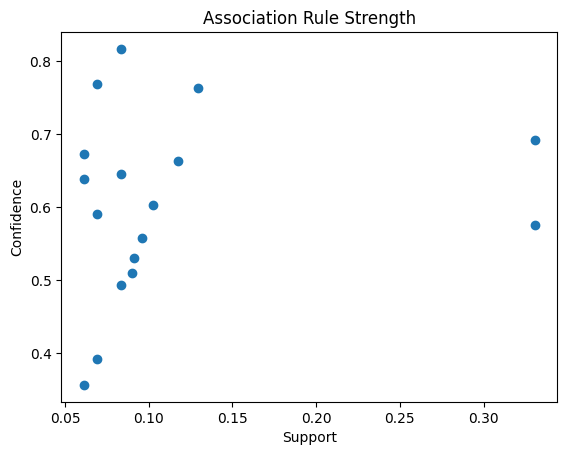

In [21]:
# ---------------------------------------------------
# STEP 11: Visualization
# ---------------------------------------------------

import matplotlib.pyplot as plt
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title("Association Rule Strength")
plt.show()
